# Week 10 — K-Means Clustering and Silhouette Analysis

**Dataset:** Marketing and Product Performance (synthetic; 10,000 campaigns)  
**Week 10 objective:** Use K-means clustering, the elbow method, silhouette score, feature scaling, and Euclidean distance to investigate whether the recorded campaign attributes form distinct profiles.

This notebook is a self-contained Week 10 submission. Clustering is exploratory: it will not call groups meaningful unless separation, stability, and profile summaries support that conclusion.

## 1. Analytical design

**Question.** Do non-identifier campaign, product, customer, and promotional attributes form well-separated K-means profiles?

**Feature scope.** Revenue is held out of the clustering input so it can be used afterward to describe—not define—any clusters. One-of-a-kind IDs are removed. Numeric variables are standardized and the two low-cardinality categorical variables are one-hot encoded.

**Evaluation plan.** K-means is fitted for `k = 2` through `8`. Inertia (within-cluster sum of squares) supports the elbow method; mean silhouette score measures separation and cohesion. K-means uses Euclidean geometry because its centroid minimizes squared Euclidean distance.

In [ ]:
# Standard-library configuration
import warnings

# Data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Unsupervised-learning tools
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Keep routine output focused on the analysis and use a consistent visual style.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
RANDOM_STATE = 42

# Load the selected marketing and product performance dataset.
DATA_PATH = 'marketing_and_product_performance.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.head())


Dataset shape: 10,000 rows × 17 columns


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


## 2. Data audit and feature preparation

Feature scaling is essential for K-means: without it, large-unit variables such as budget would dominate Euclidean distance. The data audit verifies completeness and identifies one-of-a-kind IDs that would create artificial distinctions.

In [2]:
# Summarize data types, completeness, and cardinality before clustering.
audit = pd.DataFrame(
    {
        'data_type': df.dtypes.astype(str),
        'missing_values': df.isna().sum(),
        'unique_values': df.nunique(),
    }
)
display(audit)

# Exclude one-of-a-kind labels: they identify records but do not describe reusable profiles.
identifier_columns = [
    'Campaign_ID',
    'Product_ID',
    'Customer_ID',
    'Flash_Sale_ID',
    'Bundle_ID',
]

# Hold revenue out of K-means so it can later describe, rather than define, profiles.
cluster_features = df.drop(
    columns=identifier_columns + ['Revenue_Generated']
)

numeric_features = (
    cluster_features.select_dtypes(include=np.number)
    .columns
    .tolist()
)
categorical_features = (
    cluster_features.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print('Numeric clustering features:')
print(numeric_features)
print()
print('Categorical clustering features:')
print(categorical_features)
print()
print(f'Total clustering features before encoding: {cluster_features.shape[1]}')


,data_type,missing_values,unique_values
Campaign_ID,str,0,10000
Product_ID,str,0,10000
Budget,float64,0,9995
Clicks,int64,0,4298
Conversions,int64,0,999
Revenue_Generated,float64,0,9997
ROI,float64,0,451
Customer_ID,str,0,10000
Subscription_Tier,str,0,3
Subscription_Length,int64,0,35


Numeric clustering features:
['Budget', 'Clicks', 'Conversions', 'ROI', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund']

Categorical clustering features:
['Subscription_Tier', 'Common_Keywords']

Total clustering features before encoding: 11


### Data-quality and feature-scope finding

The audit confirms **10,000 complete records** with no missing values. Five ID fields are unique for every record and are correctly excluded: including them would add artificial distance between campaigns. The final clustering input contains nine numeric and two categorical business descriptors; revenue remains outside the fitting matrix so it cannot manufacture revenue-based clusters.


### Step 2.1 — Exploratory data analysis for clustering

Before clustering, I examine the distributions and descriptive differences in observed campaign outcomes. This EDA does not define the clusters or establish causation. Instead, it identifies scale differences, potential outliers, and whether the attributes appear to have obvious business structure worth testing with K-means.

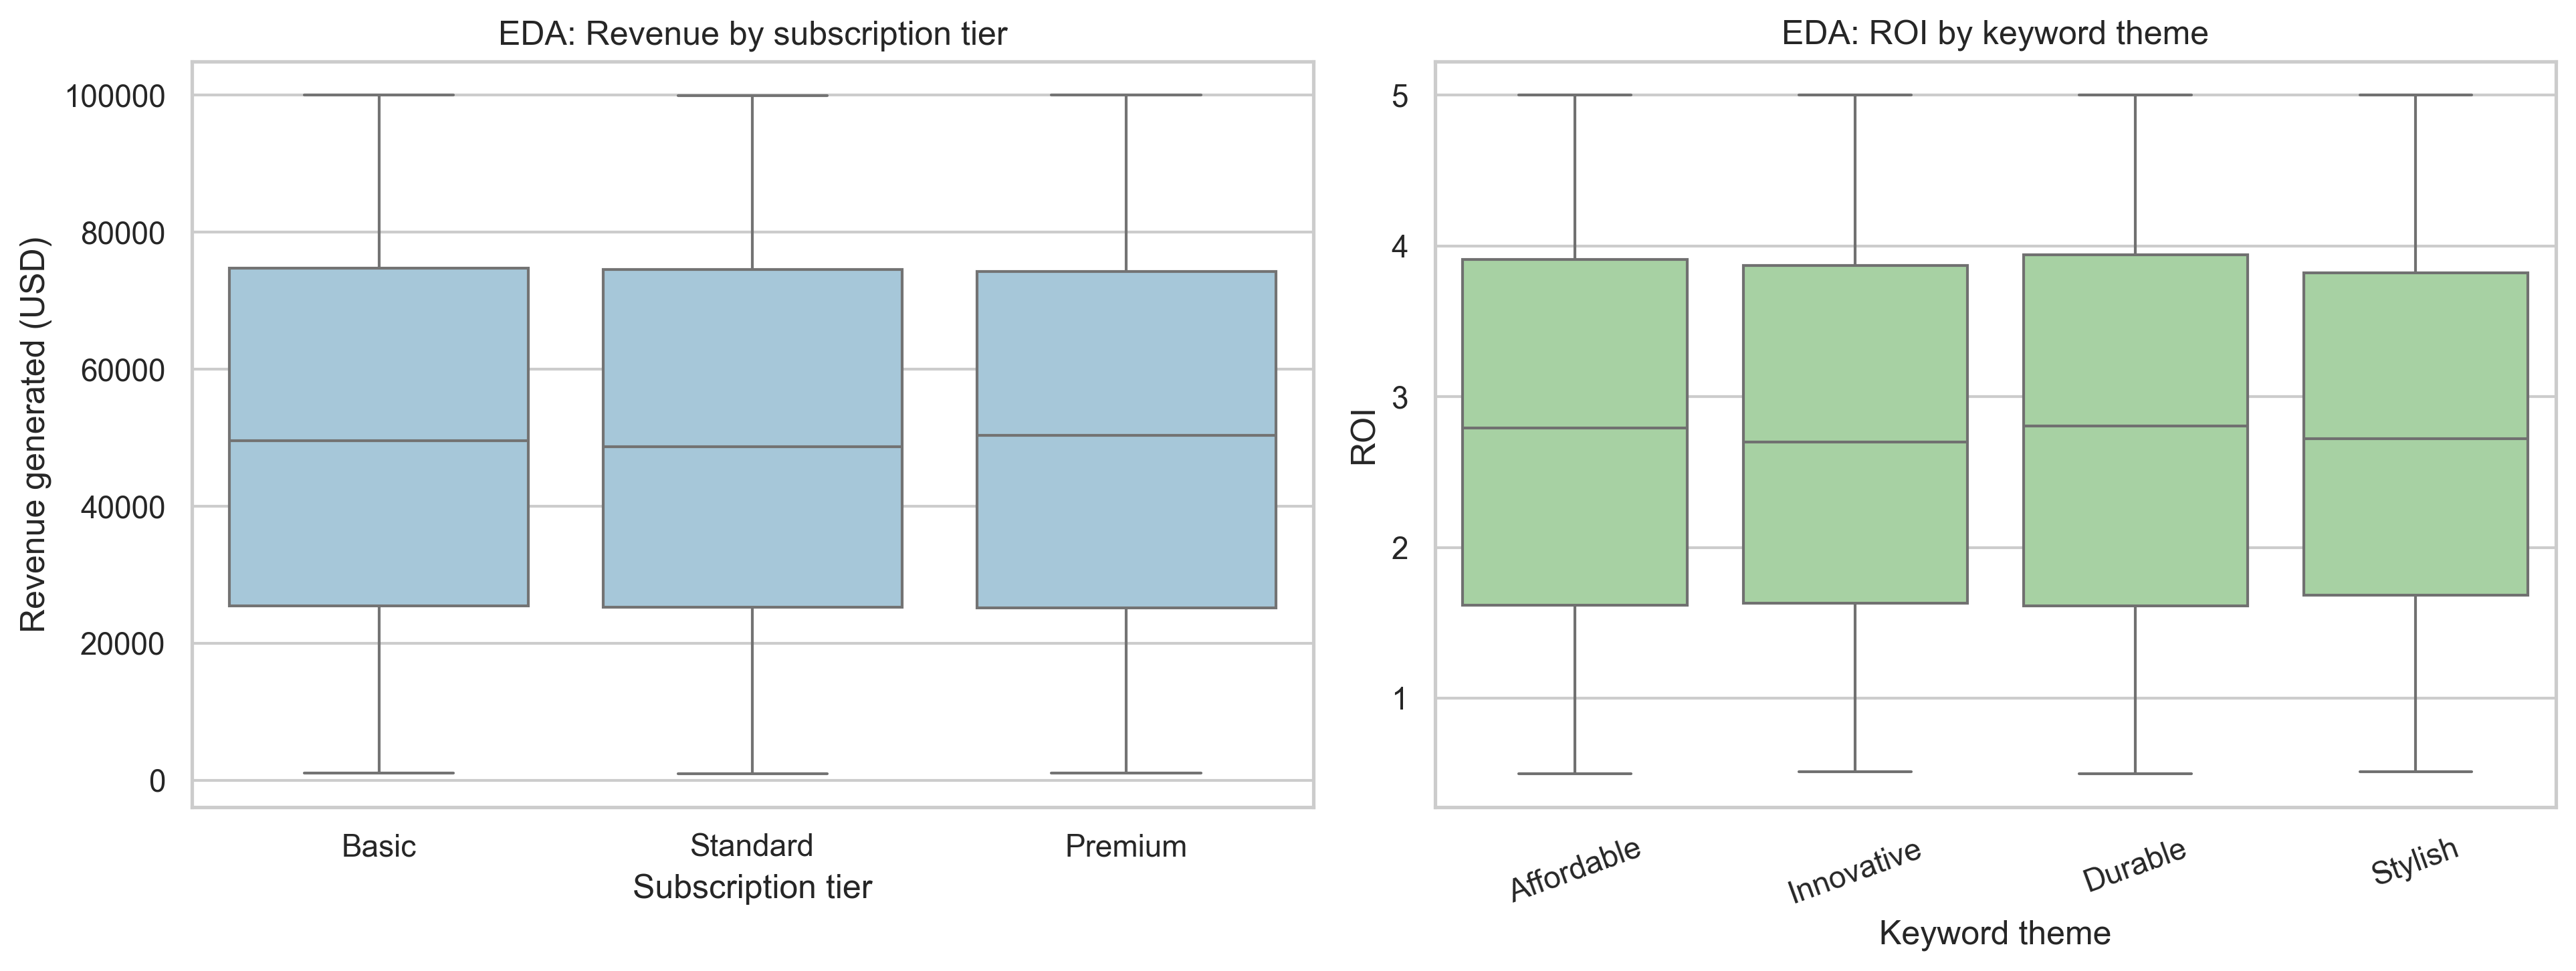

,Budget,Clicks,Conversions,Revenue_Generated,ROI,Units_Sold
Subscription_Tier,,,,,,
Basic,25234.68,2442.78,503.76,50157.92,2.79,101.79
Premium,25191.96,2528.04,500.58,50093.14,2.74,99.95
Standard,25364.85,2476.49,492.43,49860.90,2.74,100.28


These summaries are descriptive; they motivate clustering but do not prove a stable segmentation.


In [3]:
# Compare observed revenue and ROI across two low-cardinality business descriptors.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=df,
    x='Subscription_Tier',
    y='Revenue_Generated',
    order=['Basic', 'Standard', 'Premium'],
    color='#9ECAE1',
    ax=axes[0],
)
axes[0].set_title('EDA: Revenue by subscription tier')
axes[0].set_xlabel('Subscription tier')
axes[0].set_ylabel('Revenue generated (USD)')

sns.boxplot(
    data=df,
    x='Common_Keywords',
    y='ROI',
    color='#A1D99B',
    ax=axes[1],
)
axes[1].set_title('EDA: ROI by keyword theme')
axes[1].set_xlabel('Keyword theme')
axes[1].set_ylabel('ROI')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

eda_profile = (
    df.groupby('Subscription_Tier')[
        ['Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'ROI', 'Units_Sold']
    ]
    .mean()
    .round(2)
)
display(eda_profile)
print('These summaries are descriptive; they motivate clustering but do not prove a stable segmentation.')


### EDA finding: no obvious segment signal before clustering

The subscription-tier summaries are very similar: mean revenue is approximately $50,000 and mean ROI is approximately 2.7–2.8 for all three tiers. This does not rule out multivariable structure, but it sets an appropriate expectation: the data do not show a strong, obvious business separation before K-means. The EDA motivates testing the clustering assumption rather than presuming useful segments exist.


Clustering matrix shape: (10000, 16)


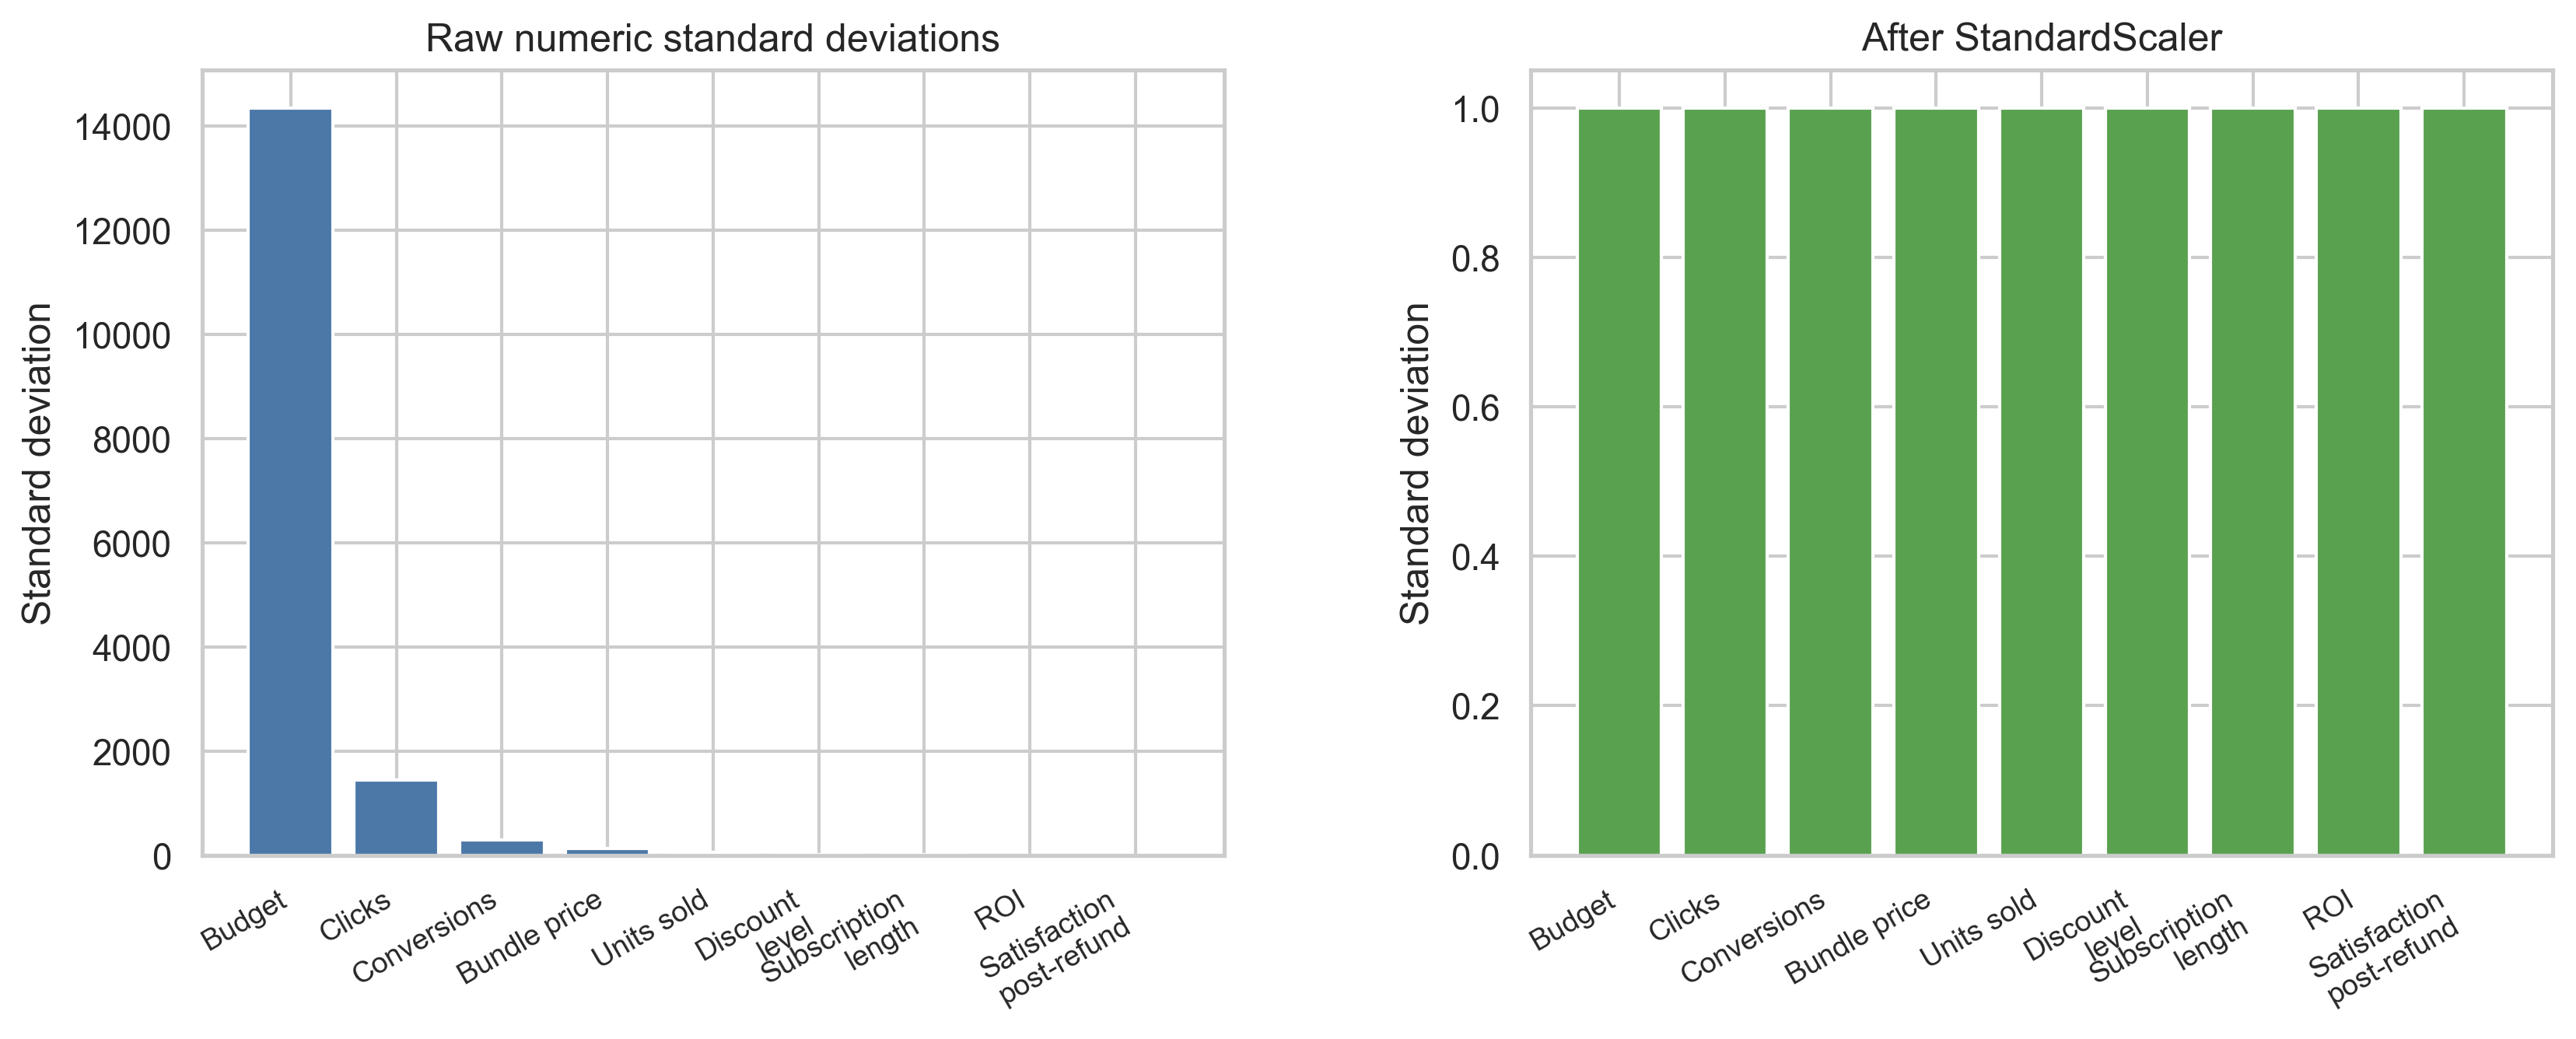

In [4]:
# Standardize numeric variables so no large-unit feature dominates Euclidean distance.
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            categorical_features,
        ),
    ]
)

# Fit preprocessing once to create the matrix used by every K-means model.
X_cluster = preprocessor.fit_transform(cluster_features)
print('Clustering matrix shape:', X_cluster.shape)

# Compare feature scale before and after standardization.
feature_labels = {
    'Budget': 'Budget',
    'Clicks': 'Clicks',
    'Conversions': 'Conversions',
    'ROI': 'ROI',
    'Subscription_Length': 'Subscription\nlength',
    'Discount_Level': 'Discount\nlevel',
    'Units_Sold': 'Units sold',
    'Bundle_Price': 'Bundle price',
    'Customer_Satisfaction_Post_Refund': 'Satisfaction\npost-refund',
}

raw_standard_deviations = (
    cluster_features[numeric_features]
    .std()
    .sort_values(ascending=False)
)

scaled_numeric = pd.DataFrame(
    X_cluster[:, : len(numeric_features)],
    columns=numeric_features,
)
scaled_standard_deviations = scaled_numeric.std().reindex(
    raw_standard_deviations.index
)
display_labels = [feature_labels[name] for name in raw_standard_deviations.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharex=True)

axes[0].bar(
    display_labels,
    raw_standard_deviations.values,
    color='#4C78A8',
)
axes[0].set_title('Raw numeric standard deviations')
axes[0].set_ylabel('Standard deviation')

axes[1].bar(
    display_labels,
    scaled_standard_deviations.values,
    color='#59A14F',
)
axes[1].set_title('After StandardScaler')
axes[1].set_ylabel('Standard deviation')

for axis in axes:
    axis.tick_params(axis='x', labelrotation=30, labelsize=9)
    for label in axis.get_xticklabels():
        label.set_ha('right')

fig.subplots_adjust(bottom=0.30, wspace=0.30)
plt.show()


### Preprocessing check

The raw-scale chart shows why scaling is required: Budget and Clicks have much larger numeric variation than satisfaction or ROI. After StandardScaler, all numeric features have comparable spread, so Euclidean distance reflects a combination of attributes rather than primarily the largest-unit variable. One-hot encoding adds the categorical descriptors without imposing a false ordinal order on tier or keyword.


## 3. K-means, the elbow method, and silhouette score

K-means repeatedly assigns each campaign to its nearest centroid and updates centroids to the mean of their assigned points. **Inertia** always decreases as `k` increases, so the elbow method looks for diminishing returns. **Silhouette score** compares a point’s average distance within its cluster with its distance to the nearest other cluster; higher values indicate clearer separation. Silhouette is more computationally expensive, so the calculation below uses a reproducible 2,500-record sample while K-means itself uses all 10,000 records.

In [5]:
# Fit K-means on the full standardized matrix for each candidate number of clusters.
k_values = range(2, 9)
evaluation_records = []
models = {}

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
    )
    labels = kmeans.fit_predict(X_cluster)

    evaluation_records.append(
        {
            'k': k,
            'inertia': kmeans.inertia_,
            'silhouette': silhouette_score(
                X_cluster,
                labels,
                sample_size=2500,
                random_state=RANDOM_STATE,
            ),
            'smallest_cluster': pd.Series(labels).value_counts().min(),
        }
    )
    models[k] = kmeans

metrics = pd.DataFrame(evaluation_records)
display(metrics.style.format({'inertia': '{:,.0f}', 'silhouette': '{:.3f}'}))

best_k = int(metrics.loc[metrics.silhouette.idxmax(), 'k'])
print(f'Highest sampled silhouette score occurs at k={best_k}.')


,k,inertia,silhouette,smallest_cluster
0,2,"96,174",0.076,4963
1,3,"91,712",0.063,3077
2,4,"88,042",0.064,2314
3,5,"85,252",0.062,1948
4,6,"82,790",0.060,1570
5,7,"80,632",0.061,1364
6,8,"78,634",0.066,1178


Highest sampled silhouette score occurs at k=2.


### Model-selection finding

Inertia decreases for every additional cluster by construction, so its downward movement alone is not evidence for a particular k. The sampled silhouette score reaches its maximum at **k = 2**, but the value is only **0.076**. Since values near zero indicate overlapping clusters, this is a weak maximum rather than convincing evidence of two naturally distinct campaign groups. The full grid is retained so the selection is auditable and not based on a single run.


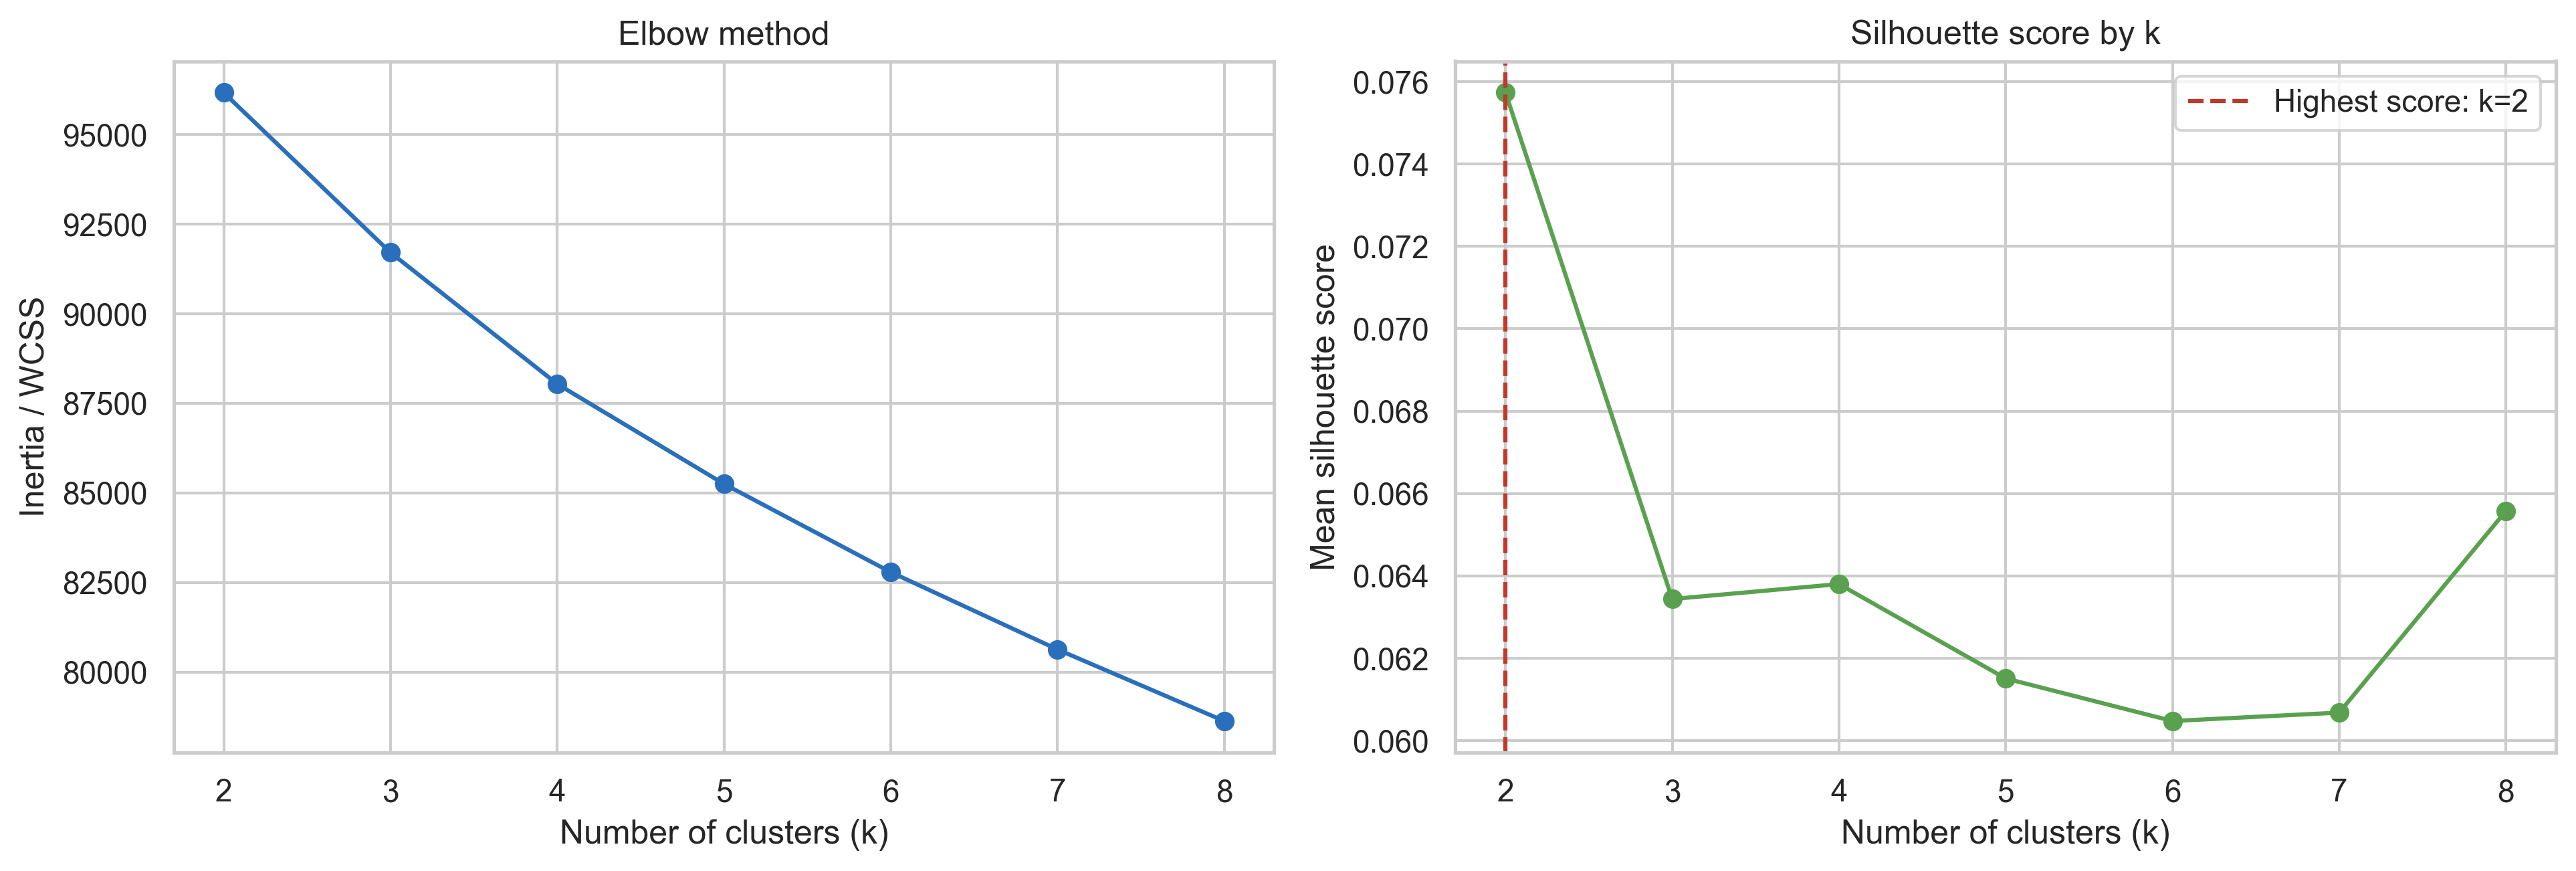

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(metrics.k, metrics.inertia, marker='o', color='#2A6FBB')
axes[0].set(title='Elbow method', xlabel='Number of clusters (k)', ylabel='Inertia / WCSS')
axes[1].plot(metrics.k, metrics.silhouette, marker='o', color='#59A14F')
axes[1].axvline(best_k, color='#C0392B', ls='--', label=f'Highest score: k={best_k}')
axes[1].set(title='Silhouette score by k', xlabel='Number of clusters (k)', ylabel='Mean silhouette score')
axes[1].legend()
plt.tight_layout()
plt.show()


### Diagnostic interpretation: elbow and silhouette agree on weak separation

The elbow curve has no sharp bend, meaning extra clusters provide only gradual reductions in within-cluster variation. The silhouette curve also stays low across every tested k. Taken together, the diagnostics support a conservative conclusion: k = 2 is the least weak tested partition, not a strong segmentation discovery. The notebook therefore reports the solution for learning and profiling purposes while avoiding an actionable-segment claim.


## 4. Selected solution, cluster diagnostics, and interpretation

The selected `k` is the silhouette-score maximum, checked against the elbow curve and cluster sizes. A high score is not enough by itself: campaigns should also occupy reasonably sized clusters and show interpretable profile differences. PCA is used only to visualize the high-dimensional clustering geometry; it is not used to fit K-means.

Selected k=2; sampled silhouette=0.076


,campaigns
Cluster,
0,4963
1,5037


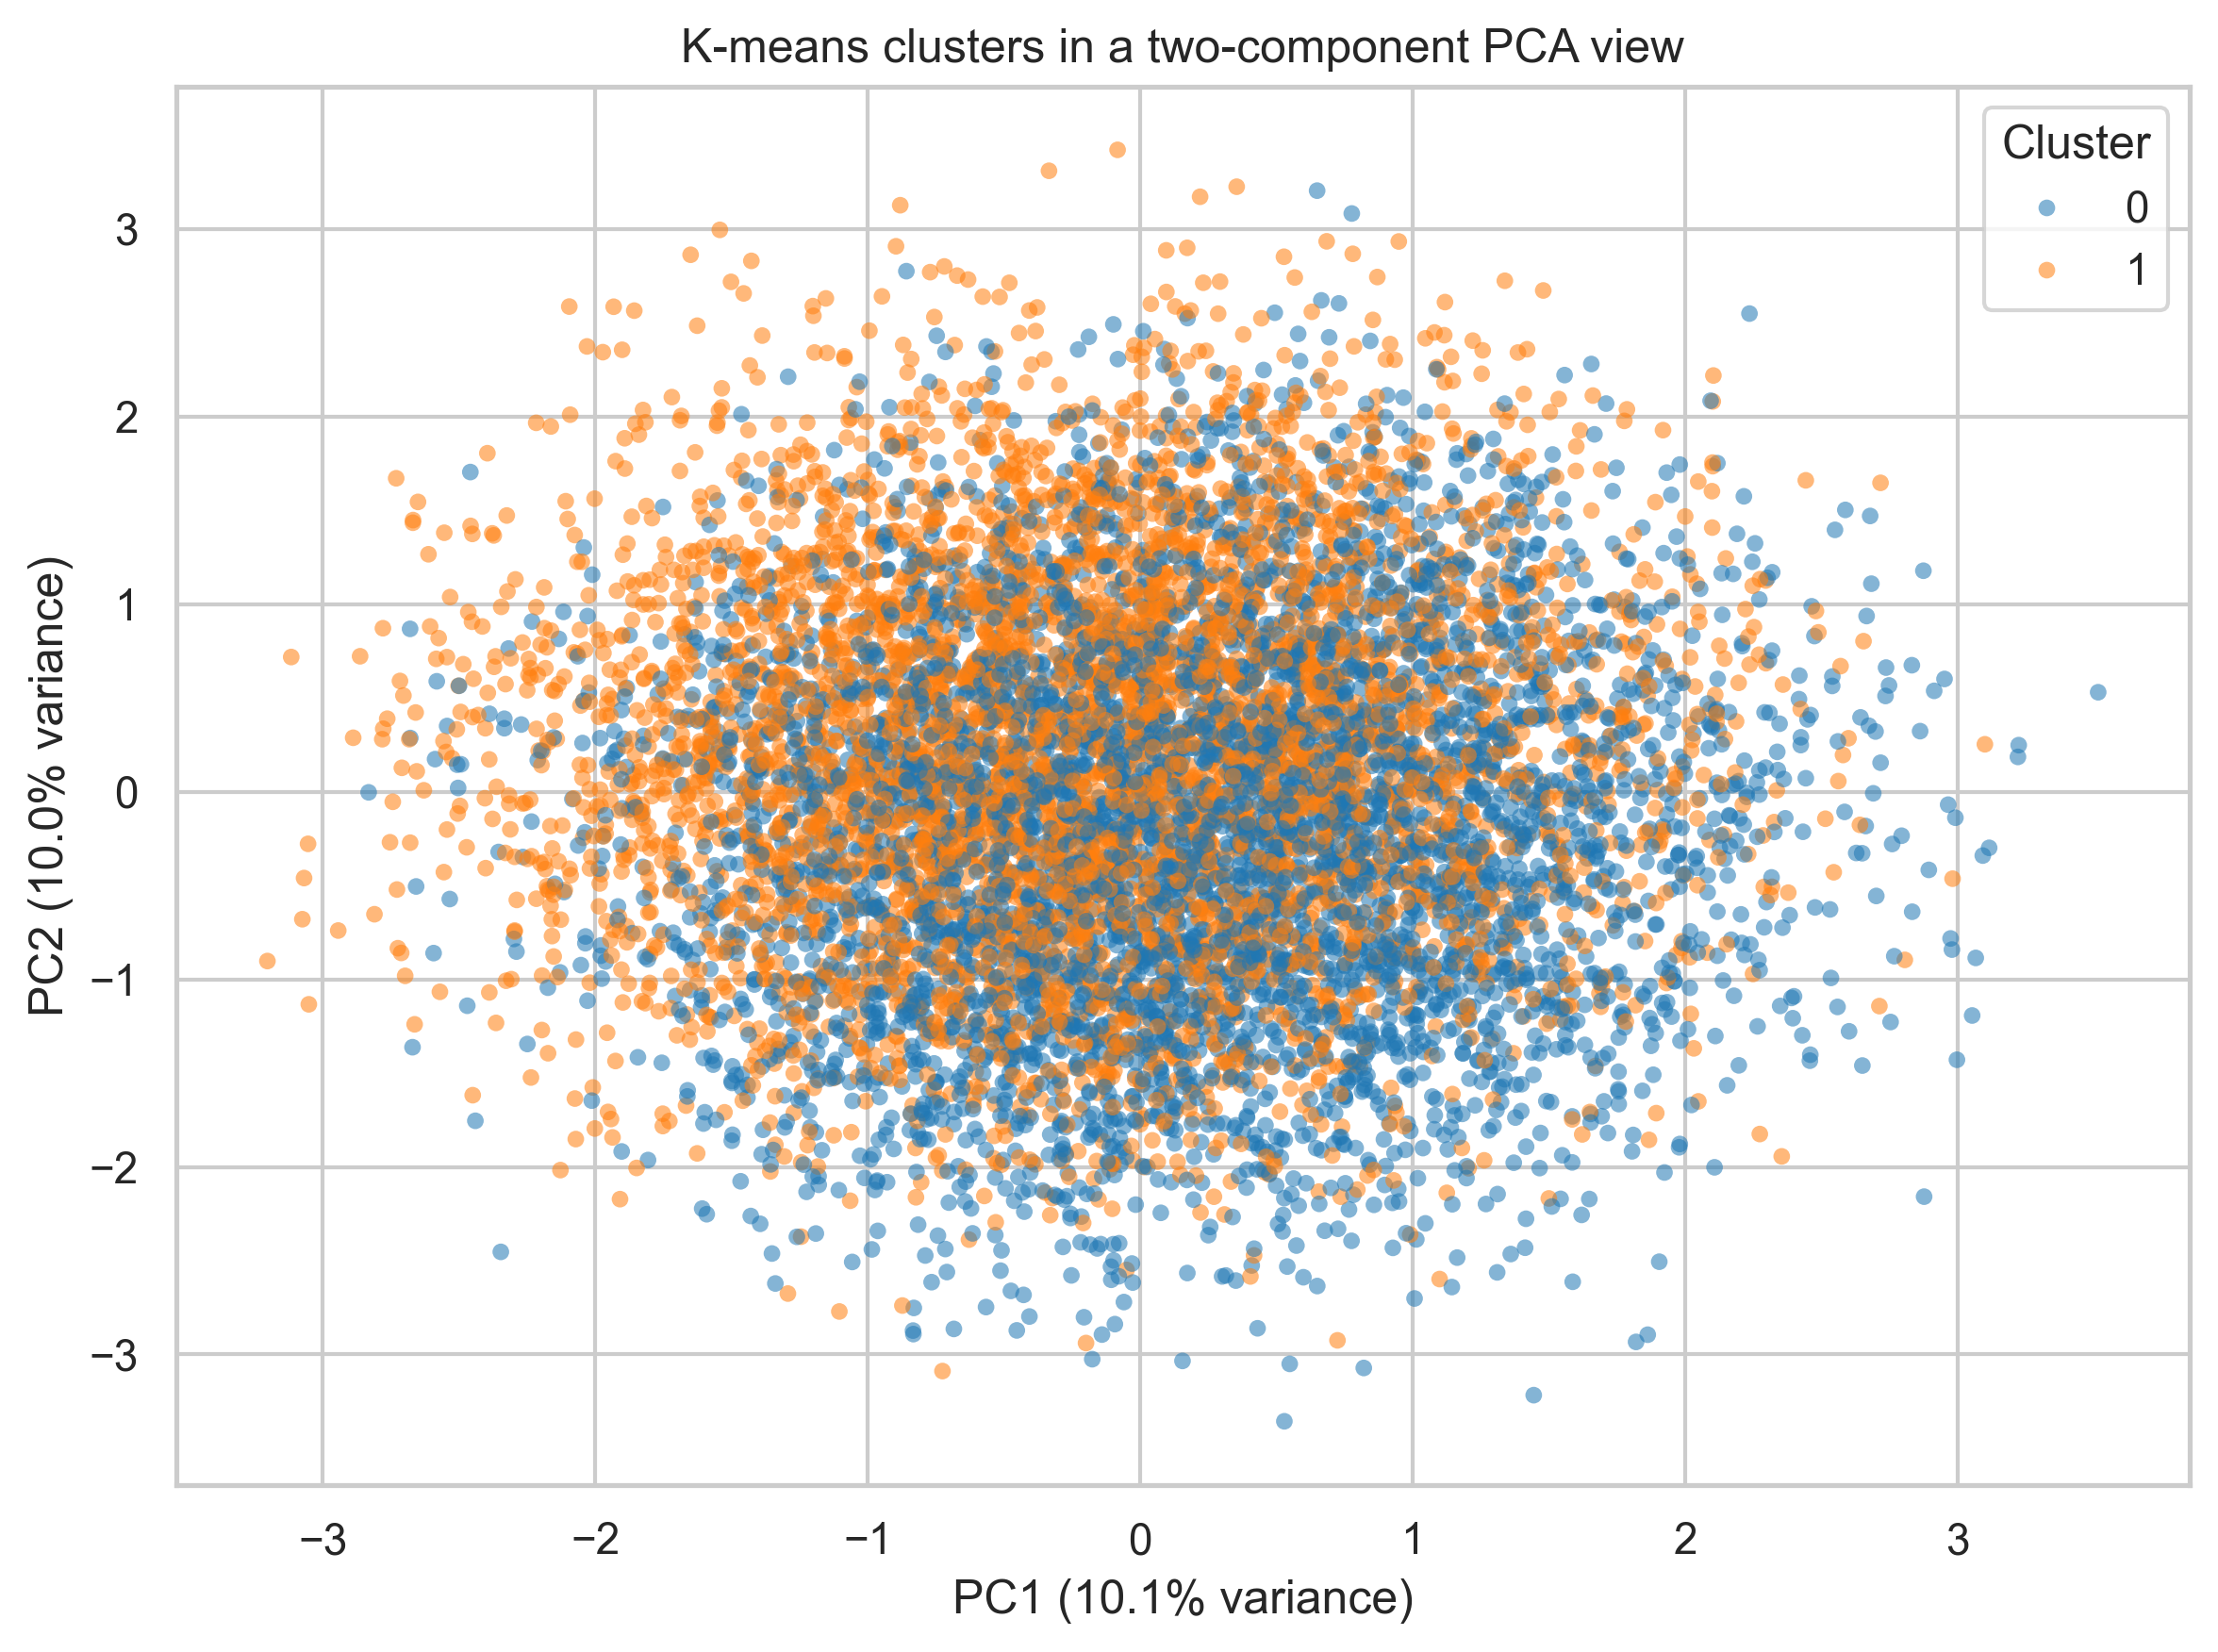

In [7]:
# Reuse the selected full-data K-means solution for cluster diagnostics.
selected_model = models[best_k]
labels = selected_model.labels_

df_results = df.copy()
df_results['Cluster'] = labels

selected_silhouette = silhouette_score(
    X_cluster,
    labels,
    sample_size=2500,
    random_state=RANDOM_STATE,
)
cluster_sizes = df_results['Cluster'].value_counts().sort_index()

print(f'Selected k={best_k}; sampled silhouette={selected_silhouette:.3f}')
display(cluster_sizes.to_frame('campaigns'))

# PCA is used only to visualize the high-dimensional K-means geometry.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=pca_coordinates[:, 0],
    y=pca_coordinates[:, 1],
    hue=labels,
    palette='tab10',
    s=18,
    alpha=0.55,
    linewidth=0,
)
plt.title('K-means clusters in a two-component PCA view')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


### Selected-solution diagnostic

The selected partition contains **4,963 and 5,037 campaigns**, so the low silhouette is not caused by a tiny leftover cluster. The PCA visualization is only a two-dimensional projection of the 16-column transformed matrix; it should be used to communicate overlap, not as proof that the full-dimensional clusters are separate. The visible overlap is consistent with the low silhouette score.


,Budget,Clicks,Conversions,ROI,Units_Sold,Discount_Level,Bundle_Price,Subscription_Length,Customer_Satisfaction_Post_Refund,Revenue_Generated
Cluster,,,,,,,,,,
0,25317.41,2466.58,500.12,2.75,100.47,39.23,273.87,17.90,3.50,49934.06
1,25210.60,2497.00,497.85,2.76,100.91,39.61,276.51,18.13,1.51,50141.66


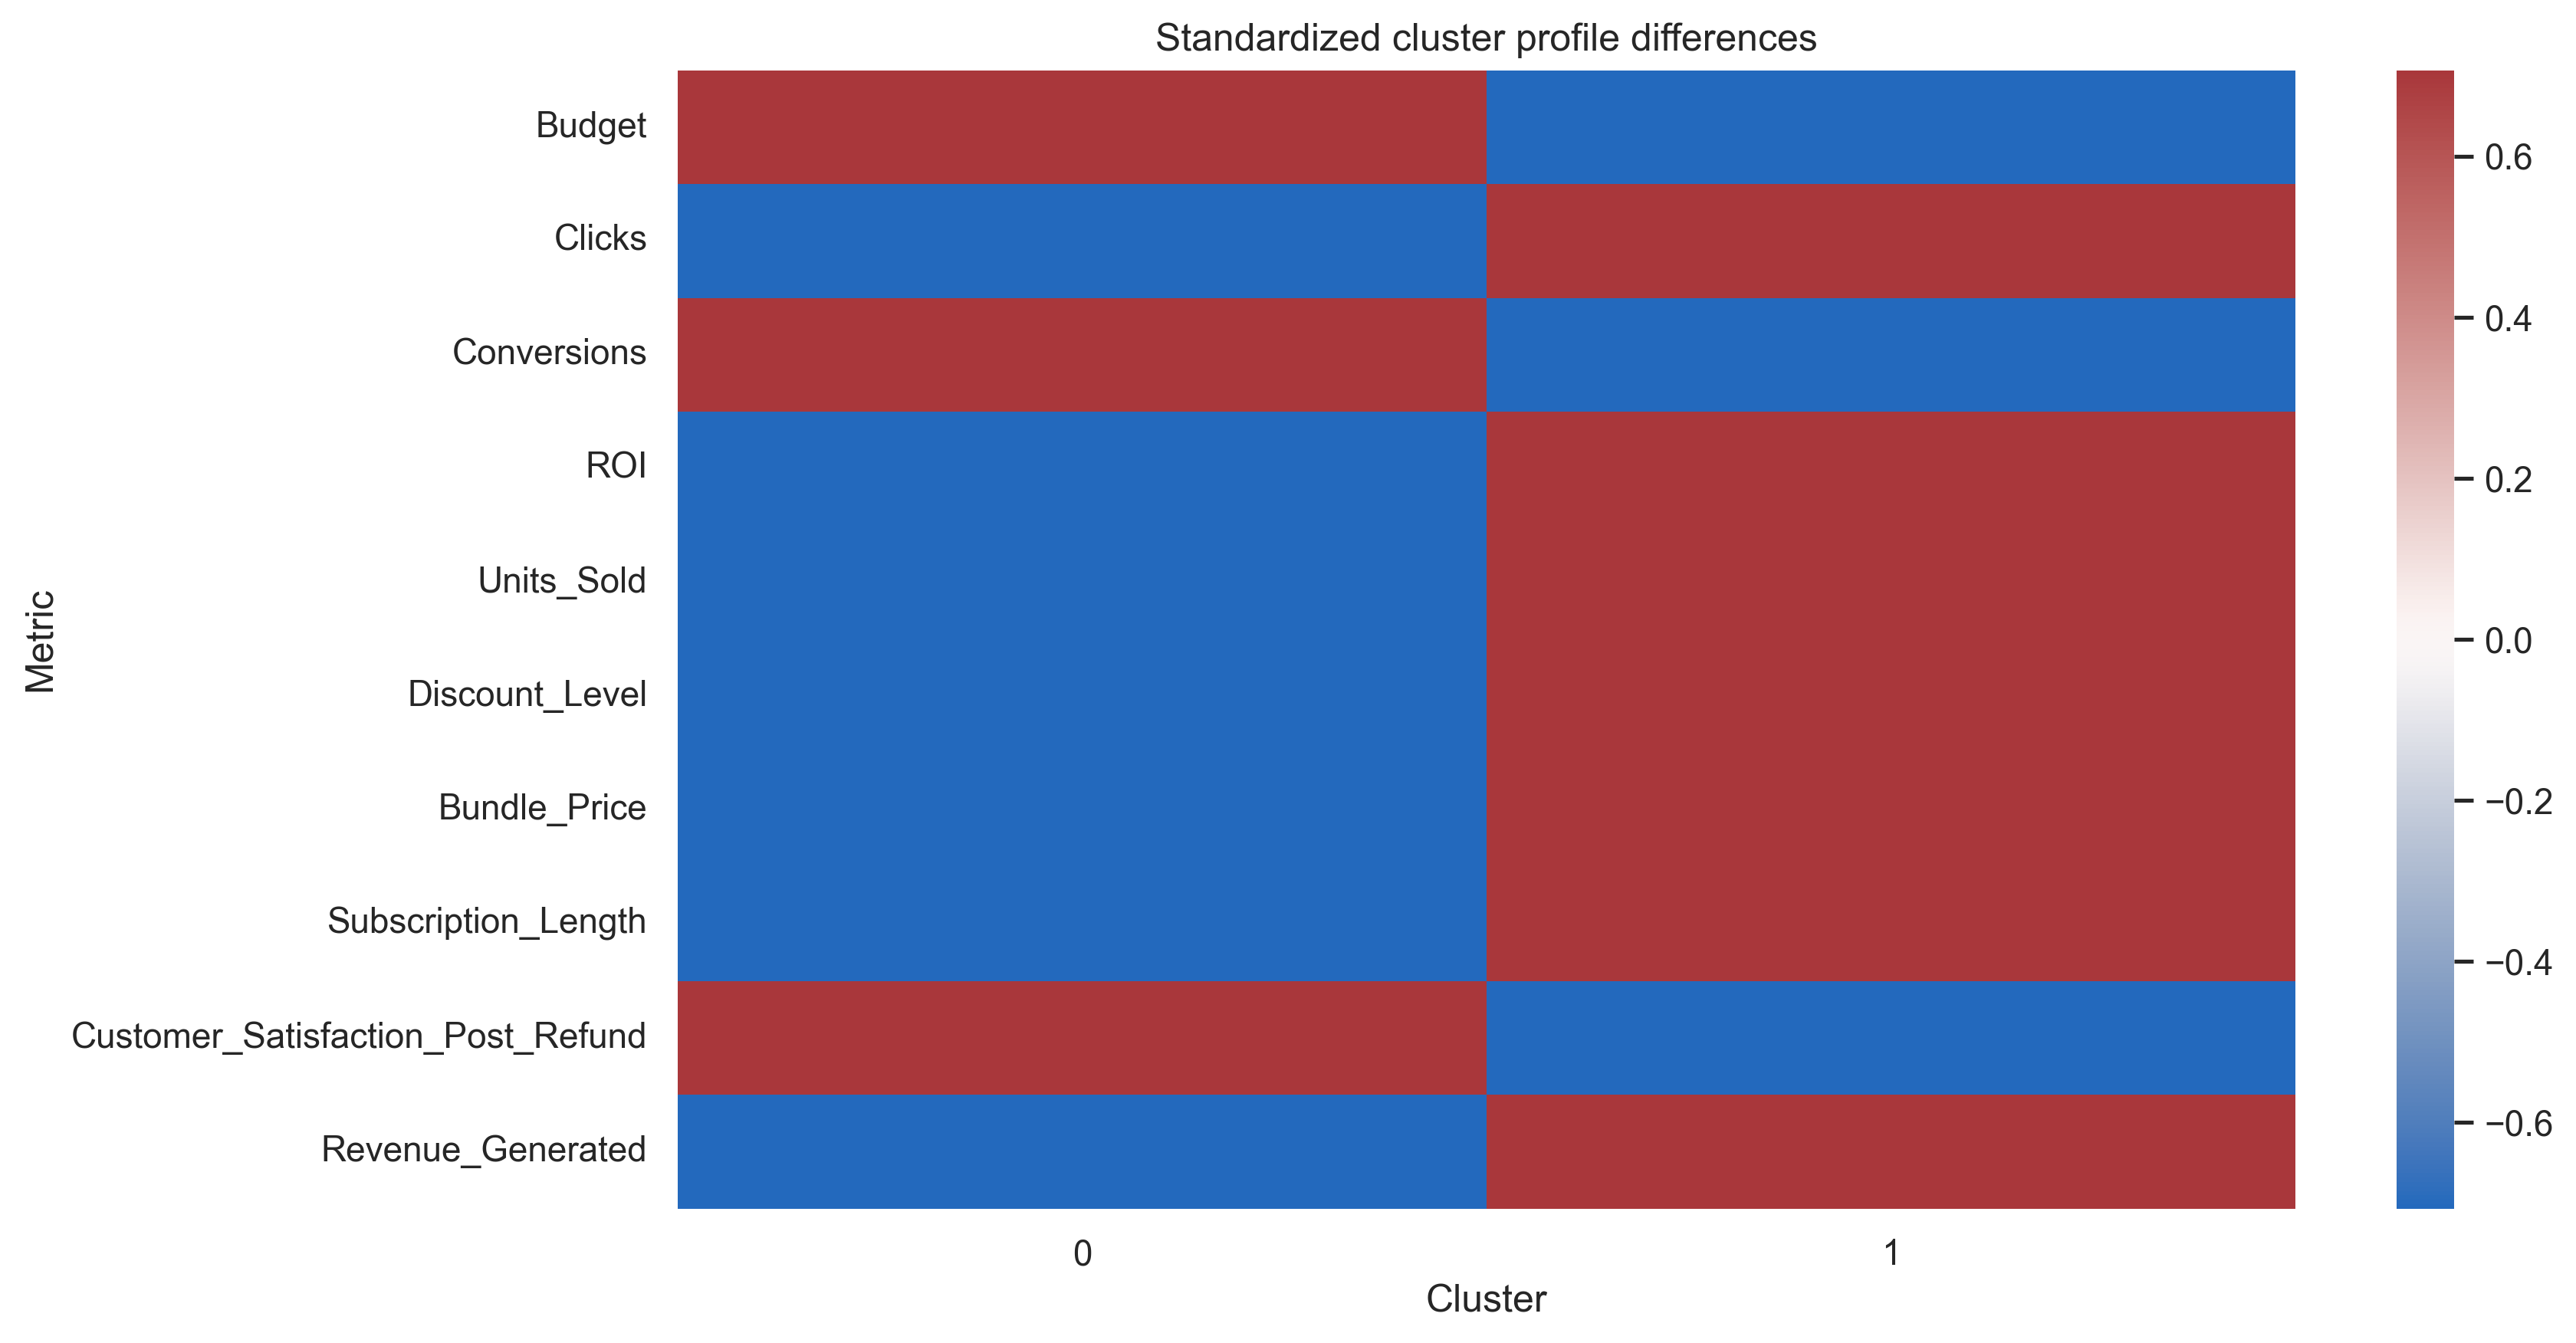

In [8]:
# Revenue is reserved for profile description rather than K-means input.
profile_columns = [
    'Budget',
    'Clicks',
    'Conversions',
    'ROI',
    'Units_Sold',
    'Discount_Level',
    'Bundle_Price',
    'Subscription_Length',
    'Customer_Satisfaction_Post_Refund',
    'Revenue_Generated',
]

cluster_profiles = (
    df_results.groupby('Cluster')[profile_columns]
    .mean()
    .round(2)
)
display(cluster_profiles)

# Standardized profile means make between-cluster differences easier to compare visually.
profile_z_scores = (
    cluster_profiles - cluster_profiles.mean()
) / cluster_profiles.std()

plt.figure(figsize=(12, 6))
sns.heatmap(profile_z_scores.T, cmap='vlag', center=0, annot=False)
plt.title('Standardized cluster profile differences')
plt.xlabel('Cluster')
plt.ylabel('Metric')
plt.tight_layout()
plt.show()


### Profile interpretation and limitation

The two profile averages are nearly identical for most campaign attributes and have very similar mean revenue (about $49.9K versus $50.1K). The clearest difference is average post-refund satisfaction, which reflects how K-means partitioned the standardized input—not a validated marketing outcome. Revenue was excluded from fitting, so the similar revenue means appropriately reinforce the conclusion that these are tentative descriptive profiles, not performance-based segments.


### Milestone Two evidence in this notebook

This Week 10 analysis documents the required modeling details: feature selection and scaling, the Euclidean-distance rationale, elbow and silhouette evaluation, parameter choice (`k`), cluster-size checks, expected/ unexpected results, and quantitative conclusions. The low silhouette result is reported as evidence that the synthetic data do not form strongly separated K-means groups—not as a reason to overstate the clusters.

## 5. Results and clustering safeguards

The highest sampled silhouette score occurred at **k = 2**, but the score was only **0.076**. The elbow curve decreased gradually rather than showing a sharp, persuasive bend, and the two selected clusters were nearly equal in size (4,963 and 5,037 campaigns). Together, these results indicate weak separation: K-means can partition the data, but the geometry does not support describing the groups as strongly distinct campaign segments.

Clustering has no train/test target error, so its main risks are choosing an arbitrary number of clusters or describing noise as a segment. The safeguards here are standardized inputs, multiple `k` values, inertia plus silhouette diagnostics, fixed random seed with `n_init=20`, cluster-size review, and revenue reserved for profile description rather than cluster assignment.

This is a supported finding for the synthetic dataset. The profile table and PCA plot remain useful exploratory diagnostics, but the low silhouette score means that any differences should be framed as tentative descriptive patterns—not actionable or causal market segments.

## 6. Week 10 “Think About It” answers

**When use K-means?** Use it when observations can reasonably be represented by numeric feature vectors and the goal is exploratory grouping around Euclidean centroids.

**When use silhouette versus elbow?** Use the elbow method to inspect diminishing inertia returns and silhouette to quantify cohesion versus separation. They complement one another; silhouette is especially helpful when the elbow is ambiguous.

**Why Euclidean only?** K-means updates each centroid to the arithmetic mean, which minimizes the within-cluster sum of squared Euclidean distances. A different metric requires a different clustering objective and center definition.

## Rubric evidence for this week: K-means clustering

**Project relevance and potential impact.** K-means tests whether campaign, product, customer, and promotional descriptors form distinct profiles that could support differentiated marketing strategy. Establishing that profiles are weak is decision-relevant because it prevents artificial segments from being treated as actionable audiences.

**EDA role.** The audit confirmed complete data, identified IDs to remove, and showed substantial scale differences that made standardization mandatory. Tier-level EDA also showed little obvious descriptive separation, motivating a cautious clustering test rather than a presumption of segments.

**Metrics and tuning.** The analysis evaluated k = 2 through 8. Inertia measures within-cluster squared Euclidean distance and supports elbow inspection; silhouette measures cohesion relative to separation and supports comparison across k. `n_init=20` reduces sensitivity to centroid initialization, while a fixed seed makes the result reproducible.

**Unsupported-segmentation safeguards and result.** Unsupervised learning has no target-based train/test error, so its analogous risk is calling noise a segment. IDs and revenue were excluded from fitting; inputs were standardized/encoded; multiple k values, inertia, silhouette, cluster sizes, and PCA diagnostics were reviewed. The best tested silhouette was only about 0.076 at k = 2 with no sharp elbow, showing weak geometric separation rather than robust segments.

**Expected and unexpected finding.** Inertia was expected to fall as k rises. It was unexpected that no tested k produced meaningful separation despite 10,000 complete records. The two resulting profiles have nearly identical revenue means, so they are tentative descriptive partitions—not performance-based or actionable market segments.

**AI-use documentation.** Generative AI (OpenAI Codex/ChatGPT) was used to assist with code formatting and explanatory prose. The student reviewed the data, modeling choices, executed outputs, conclusions, and citations, and remains responsible for the submission.


## 7. Week 10 submission checklist and sources

This notebook includes K-means, feature scaling, Euclidean distance rationale, elbow method, silhouette score, cluster-size checks, PCA visualization, profile interpretation, regularization-style safeguards, four figures, and the Week 10 reflection answers.

### Sources

- Scikit-learn Developers. (2026). *KMeans*. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- Scikit-learn Developers. (2026). *Silhouette Coefficient*. https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient
- Shah, I. A. (2024). *Marketing and Product Performance Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/imranalishahh/marketing-and-product-performance-dataset
